In [83]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [84]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


In [85]:
train_df =  pd.read_csv('/content/drive/MyDrive/COMM075/data/train_data_ibm.csv')
test_df =  pd.read_csv('/content/drive/MyDrive/COMM075/data/test_data_ibm.csv')

In [86]:
train_df

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,OverTime,...,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Attrition
0,1.090194,1.049455,-0.899915,4,2,4,4,2,2.026752,0,...,1,0,0,0,0,0,1,0,0,0
1,-1.634828,-0.523449,-0.899915,1,3,3,1,4,-0.864408,0,...,0,0,0,0,0,0,0,1,0,0
2,0.981193,-0.992080,-0.777610,1,1,3,4,3,2.347706,0,...,1,0,0,0,0,0,0,1,0,0
3,-1.307825,-0.453653,0.445433,1,2,3,1,3,-0.956202,0,...,0,0,0,0,0,1,0,1,0,0
4,0.654191,0.491086,-0.043784,5,4,3,2,3,-0.185956,1,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,-1.525827,-0.939733,-0.288393,3,3,3,1,4,-0.917721,1,...,0,0,0,0,0,1,1,0,0,1
1172,0.109186,0.511028,-0.899915,2,2,3,2,1,0.075020,0,...,0,0,0,0,1,0,1,0,0,0
1173,-1.634828,-1.463203,-0.166088,1,2,1,1,1,-0.879886,0,...,0,0,0,0,0,0,0,1,0,0
1174,-0.108815,-0.932255,-0.899915,4,4,3,2,2,0.089853,1,...,0,0,0,1,0,0,0,1,0,0


In [87]:
X_train = train_df.drop(columns=['Attrition'])
y_train = train_df['Attrition']
X_test = test_df.drop(columns=['Attrition'])
y_test = test_df['Attrition']

Before Parameter Tuning

In [88]:
clf = svm.SVC(random_state=42)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(classification_report(y_test, pred),'\n')
ibm_acc_score_before_tuning = accuracy_score(y_test, pred)
print(f'\n Accuracy Score: {ibm_acc_score_before_tuning}')
ibm_bal_acc_score_before_tuning = balanced_accuracy_score(y_test, pred)
print(f'\n Balanced Accuracy Score: {ibm_bal_acc_score_before_tuning}')
ibm_f1_macro_before_tuning = f1_score(y_test, pred, average='macro')
print(f'\n F1 Score macro: {ibm_f1_macro_before_tuning}')
ibm_f1_weighted_before_tuning = f1_score(y_test, pred, average='weighted')
print(f'\n F1 Score weighted: {ibm_f1_weighted_before_tuning}')
ibm_auc_before_tuning = roc_auc_score(y_test, pred)
print(f'\n AUC Score: {ibm_auc_before_tuning}')


              precision    recall  f1-score   support

           0       0.85      1.00      0.92       247
           1       1.00      0.09      0.16        47

    accuracy                           0.85       294
   macro avg       0.93      0.54      0.54       294
weighted avg       0.88      0.85      0.80       294
 


 Accuracy Score: 0.8537414965986394

 Balanced Accuracy Score: 0.5425531914893617

 F1 Score macro: 0.5383941286011611

 F1 Score weighted: 0.7979392874468223

 AUC Score: 0.5425531914893617


After Parameter Tuning

In [89]:
clf = svm.SVC(random_state=42)

kfold = StratifiedKFold(n_splits=5, shuffle=True)
param_grid = [
    # Linear Kernel Grid
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1, 10],
        'class_weight': ['balanced']
    },
    # RBF Kernel Grid
    {
        'kernel': ['rbf'],
        'C': [0.1, 1],
        'gamma': [0.1, 0.01],
        'class_weight': ['balanced']
    }
]

grid_search = GridSearchCV(
    clf,
    param_grid,
    cv=kfold,
    scoring='f1_macro',
)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=SVC(random_state=42),
             param_grid=[{'C': [0.01, 0.1, 1, 10], 'class_weight': ['balanced'],
                          'kernel': ['linear']},
                         {'C': [0.1, 1], 'class_weight': ['balanced'],
                          'gamma': [0.1, 0.01], 'kernel': ['rbf']}],
             scoring='f1_macro')

In [90]:
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_}')

Best parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'rbf'}
Best score: 0.6901602499717848


In [91]:
clf = svm.SVC(kernel='rbf', C=1, gamma=0.1, class_weight='balanced')
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

In [92]:

print(classification_report(y_test, pred), '\n')
ibm_acc_score_after_tuning = accuracy_score(y_test, pred)
print(f'\n Accuracy Score: {ibm_acc_score_after_tuning}')
ibm_bal_acc_score_after_tuning = balanced_accuracy_score(y_test, pred)
print(f'\n Balanced Accuracy Score: {ibm_bal_acc_score_after_tuning}')
ibm_f1_macro_after_tuning = f1_score(y_test, pred, average='macro')
print(f'\n F1 Score macro: {ibm_f1_macro_after_tuning}')
ibm_f1_weighted_after_tuning = f1_score(y_test, pred, average='weighted')
print(f'\n F1 Score weighted: {ibm_f1_weighted_after_tuning}')
ibm_auc_after_tuning = roc_auc_score(y_test, pred)
print(f'\n AUC Score: {ibm_auc_after_tuning}')

              precision    recall  f1-score   support

           0       0.90      0.95      0.92       247
           1       0.62      0.45      0.52        47

    accuracy                           0.87       294
   macro avg       0.76      0.70      0.72       294
weighted avg       0.85      0.87      0.86       294
 


 Accuracy Score: 0.8673469387755102

 Balanced Accuracy Score: 0.6970884658454647

 F1 Score macro: 0.7207977207977208

 F1 Score weighted: 0.8584026203073822

 AUC Score: 0.6970884658454647


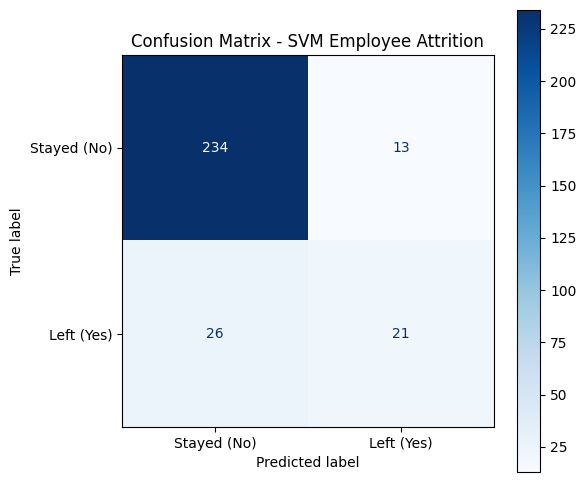

In [93]:
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed (No)', 'Left (Yes)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix - SVM Employee Attrition')
plt.show()


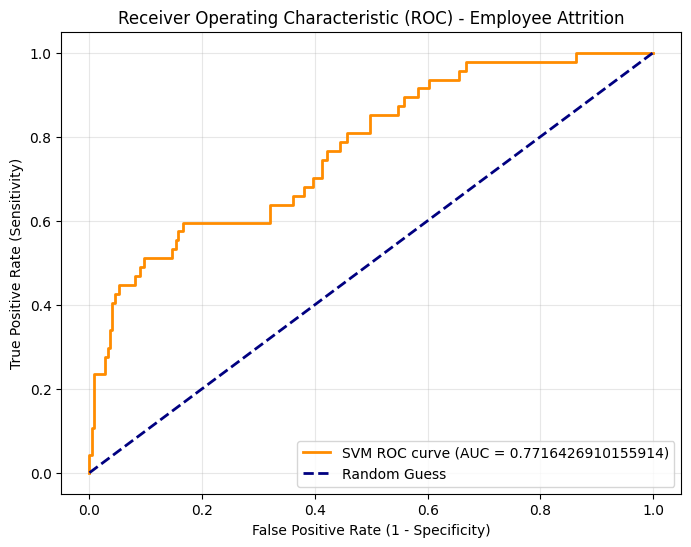

In [94]:

y_scores_ibm = clf.decision_function(X_test)

fpr_ibm, tpr_ibm, thresholds = roc_curve(y_test, y_scores_ibm)

roc_auc = auc(fpr_ibm, tpr_ibm)

plt.figure(figsize=(8, 6))

plt.plot(fpr_ibm, tpr_ibm, color='darkorange', lw=2,
         label=f'SVM ROC curve (AUC = {roc_auc:})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Guess')


plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - Employee Attrition')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)


plt.show()

In [95]:
train_df_adult = pd.read_csv('/content/drive/MyDrive/COMM075/data/adult_income_train_preprocessed_cleaned.csv')
test_df_adult = pd.read_csv('/content/drive/MyDrive/COMM075/data/adult_income_test_preprocessed_cleaned.csv')


In [96]:
train_df_adult

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,capital_net,capital_gain_log,capital_loss_log,capital_net_log,...,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Unknown,native-country_Vietnam,native-country_Yugoslavia,income_encoded
0,-0.120090,0.029521,1.138210,0,0,-0.844835,-0.131595,-0.296054,-0.220527,0.0,...,0,0,0,0,0,1,0,0,0,0
1,1.268245,0.252606,-0.804025,0,1651,-0.038454,-0.359996,-0.296054,4.466051,0.0,...,0,0,0,0,0,1,0,0,0,0
2,1.049034,-0.597440,-0.415578,0,0,-0.441645,-0.131595,-0.296054,-0.220527,0.0,...,0,0,0,0,0,1,0,0,0,0
3,2.437369,0.145539,-1.192472,0,0,-0.038454,-0.131595,-0.296054,-0.220527,0.0,...,0,0,0,0,0,1,0,0,0,0
4,0.537542,-0.789636,1.526657,0,0,-0.199731,-0.131595,-0.296054,-0.220527,0.0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39068,0.464472,-1.443693,1.138210,0,0,-0.038454,-0.131595,-0.296054,-0.220527,0.0,...,0,0,0,0,0,1,0,0,0,1
39069,1.414385,0.316735,1.138210,0,0,-1.651216,-0.131595,-0.296054,-0.220527,0.0,...,0,0,0,0,0,1,0,0,0,1
39070,1.633596,0.370416,-0.027131,0,1887,-0.038454,-0.392645,-0.296054,4.550508,0.0,...,0,0,0,0,0,1,0,0,0,1
39071,-0.047020,-1.024193,0.361316,0,0,-0.038454,-0.131595,-0.296054,-0.220527,0.0,...,0,0,0,0,0,1,0,0,0,0


In [97]:
x_train_adult = train_df_adult.drop(columns=['income_encoded'])
y_train_adult = train_df_adult['income_encoded']
x_test_adult = test_df_adult.drop(columns=['income_encoded'])
y_test_adult = test_df_adult['income_encoded']

SVM Before Tuning

In [98]:
clf = svm.SVC(random_state=42)

clf.fit(x_train_adult, y_train_adult)
pred = clf.predict(x_test_adult)

print(classification_report(y_test_adult, pred),'\n')

adult_acc_score_before_tuning = accuracy_score(y_test_adult, pred)
print(f'\n Accuracy Score: {adult_acc_score_before_tuning}')
adult_bal_acc_score_before_tuning = balanced_accuracy_score(y_test_adult, pred)
print(f'\n Balanced Accuracy Score: {adult_bal_acc_score_before_tuning}')
adult_f1_macro_before_tuning = f1_score(y_test_adult, pred, average='macro')
print(f'\n F1 Score macro: {adult_f1_macro_before_tuning}')
adult_f1_weighted_before_tuning = f1_score(y_test_adult, pred, average='weighted')
print(f'\n F1 Score weighted: {adult_f1_weighted_before_tuning}')
adult_auc_before_tuning = roc_auc_score(y_test_adult, pred)
print(f'\n AUC Score: {adult_auc_before_tuning}')

              precision    recall  f1-score   support

           0       0.81      0.97      0.88      7431
           1       0.75      0.28      0.41      2338

    accuracy                           0.81      9769
   macro avg       0.78      0.63      0.65      9769
weighted avg       0.80      0.81      0.77      9769
 


 Accuracy Score: 0.8058143105742656

 Balanced Accuracy Score: 0.62714357316856

 F1 Score macro: 0.6479228116287918

 F1 Score weighted: 0.7708426227155081

 AUC Score: 0.62714357316856


SVM After Tuning

In [99]:
x_tune, _, y_tune, _ = train_test_split(x_train_adult, y_train_adult, train_size=0.15, stratify=y_train_adult, random_state=42)

In [100]:
x_tune.shape

(5860, 89)

In [101]:
clf = svm.SVC(kernel='rbf', class_weight='balanced', random_state=42, cache_size=1000)

kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
param_grid = [
    {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.1, 0.01]
}

]
grid_search = GridSearchCV(
    clf,
    param_grid,
    cv=kfold,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(x_tune, y_tune)


Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=SVC(cache_size=1000, class_weight='balanced',
                           random_state=42),
             n_jobs=-1,
             param_grid=[{'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 0.01]}],
             scoring='f1_macro', verbose=2)

In [103]:
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_}')

Best parameters: {'C': 1, 'gamma': 0.1}
Best score: 0.7823910038065284


In [104]:
clf = svm.SVC(kernel='rbf', C=1, gamma=0.1, class_weight='balanced')
clf.fit(x_train_adult, y_train_adult)
pred = clf.predict(x_test_adult)

In [105]:
print(classification_report(y_test_adult, pred),'\n')
adult_acc_score_after_tuning = accuracy_score(y_test_adult, pred)
print(f'\n Accuracy Score: {adult_acc_score_after_tuning}')
adult_bal_acc_score_after_tuning = balanced_accuracy_score(y_test_adult, pred)
print(f'\n Balanced Accuracy Score: {adult_bal_acc_score_after_tuning}')
adult_f1_macro_after_tuning = f1_score(y_test_adult, pred, average='macro')
print(f'\n F1 Score macro: {adult_f1_macro_after_tuning}')
adult_f1_weighted_after_tuning = f1_score(y_test_adult, pred, average='weighted')
print(f'\n F1 Score weighted: {adult_f1_weighted_after_tuning}')
adult_auc_after_tuning = roc_auc_score(y_test_adult, pred)
print(f'\n AUC Score: {adult_auc_after_tuning}')


              precision    recall  f1-score   support

           0       0.95      0.82      0.88      7431
           1       0.60      0.87      0.71      2338

    accuracy                           0.83      9769
   macro avg       0.78      0.84      0.79      9769
weighted avg       0.87      0.83      0.84      9769
 


 Accuracy Score: 0.8296652676834886

 Balanced Accuracy Score: 0.841866327901323

 F1 Score macro: 0.7941229425106145

 F1 Score weighted: 0.8387194101394512

 AUC Score: 0.841866327901323


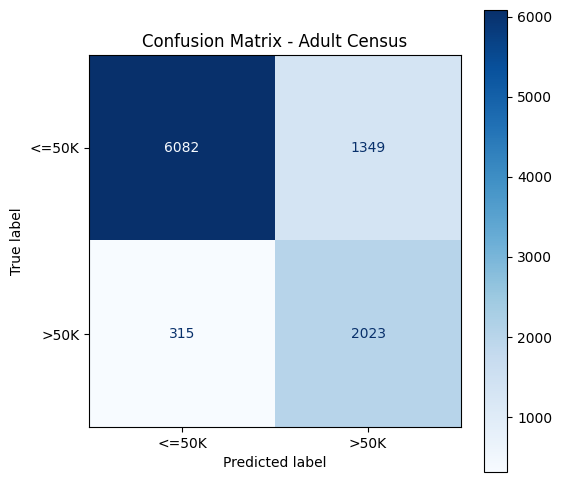

In [106]:
cm = confusion_matrix(y_test_adult, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')

# Add a title and display
plt.title('Confusion Matrix - Adult Census')
plt.show()


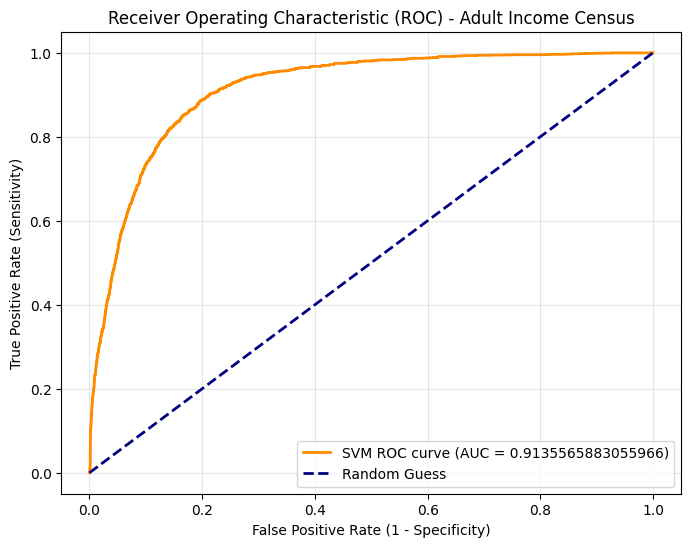

In [107]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_scores_adult = clf.decision_function(x_test_adult)

adult_fpr, adult_tpr, thresholds = roc_curve(y_test_adult, y_scores_adult)

roc_auc = auc(adult_fpr, adult_tpr)

plt.figure(figsize=(8, 6))

plt.plot(adult_fpr, adult_tpr, color='darkorange', lw=2,
         label=f'SVM ROC curve (AUC = {roc_auc:})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Guess')


plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - Adult Income Census')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)


plt.show()

Metrics for IBM HR Attrition

In [108]:
print(f'\n Accuracy Score ibm after tuning: {ibm_acc_score_after_tuning}')
print(f'\n Balanced Accuracy Score ibm after tuning: {ibm_bal_acc_score_after_tuning}')
print(f'\n F1 Score macro ibm after tuning: {ibm_f1_macro_after_tuning}')
print(f'\n F1 Score weighted ibm after tuning: {ibm_f1_weighted_after_tuning}')
print(f'\n AUC Score ibm after tuning: {ibm_auc_after_tuning}')


 Accuracy Score ibm after tuning: 0.8673469387755102

 Balanced Accuracy Score ibm after tuning: 0.6970884658454647

 F1 Score macro ibm after tuning: 0.7207977207977208

 F1 Score weighted ibm after tuning: 0.8584026203073822

 AUC Score ibm after tuning: 0.6970884658454647


Metrics for Adult Income Census

In [109]:
print(f'\n Accuracy Score adult after tuning: {adult_acc_score_after_tuning}')
print(f'\n Balanced Accuracy Score adult after tuning: {adult_bal_acc_score_after_tuning}')
print(f'\n F1 Score macroadult after tuning: {adult_f1_macro_after_tuning}')
print(f'\n F1 Score weighted adult after tuning: {adult_f1_weighted_after_tuning}')
print(f'\n AUC Score adult after tuning: {adult_auc_after_tuning}')


 Accuracy Score adult after tuning: 0.8296652676834886

 Balanced Accuracy Score adult after tuning: 0.841866327901323

 F1 Score macroadult after tuning: 0.7941229425106145

 F1 Score weighted adult after tuning: 0.8387194101394512

 AUC Score adult after tuning: 0.841866327901323


Saving results in a csv file

In [111]:
PROJECT_DIR = '/content/drive/MyDrive/COMM075'
RESULTS_DIR_IBM = os.path.join(PROJECT_DIR, 'resultsibm')
os.makedirs(RESULTS_DIR_IBM, exist_ok=True)
RESULTS_DIR_ADULT = os.path.join(PROJECT_DIR, 'resultsadult')
os.makedirs(RESULTS_DIR_ADULT, exist_ok=True)


my_results_ibm = pd.DataFrame([
    {
        'ibm_accuracy': ibm_acc_score_after_tuning,
        'ibm_balanced_accuracy': ibm_bal_acc_score_after_tuning,
        'ibm_macro_f1': ibm_f1_macro_after_tuning,
        'ibm_weighted_f1': ibm_f1_weighted_after_tuning,
        'ibm_roc_auc': ibm_auc_after_tuning,

    }
])

results_path_ibm = os.path.join(RESULTS_DIR_IBM, 'results_ibm.csv')
my_results_ibm.to_csv(results_path_ibm, index=False)

roc_ibm_df = pd.DataFrame({
    'ibm_fpr': fpr_ibm,
    'ibm_tpr': tpr_ibm
})

roc_ibm_df.to_csv(
    os.path.join(RESULTS_DIR_IBM, 'ibm_roc.csv'),
    index=False
)

scores_df_ibm = pd.DataFrame({
    'y_scores_ibm': y_scores_ibm
})

scores_df_ibm.to_csv(os.path.join(RESULTS_DIR_IBM,'y_scores_ibm.csv'), index=False)

my_results_adult = pd.DataFrame([
    {
        'adult_accuracy': adult_acc_score_after_tuning,
        'adult_balanced_accuracy': adult_bal_acc_score_after_tuning,
        'adult_macro_f1': adult_f1_macro_after_tuning,
        'adult_weighted_f1': adult_f1_weighted_after_tuning,
        'adult_roc_auc': adult_auc_after_tuning,

    }
])

results_path_adult = os.path.join(RESULTS_DIR_ADULT, 'results_adult.csv')
my_results_adult.to_csv(results_path_adult, index=False)

roc_adult_df = pd.DataFrame({
    'adult_fpr': adult_fpr,
    'adult_tpr': adult_tpr
})

roc_adult_df.to_csv(
    os.path.join(RESULTS_DIR_ADULT, 'adult_roc.csv'),
    index=False
)

scores_df_adult = pd.DataFrame({
    'y_scores_adult': y_scores_adult
})

scores_df_adult.to_csv(os.path.join(RESULTS_DIR_ADULT,'y_scores_adult.csv'), index=False)